# Δν Measurement — Comb + Échelle

Slide until dashed lines hit peaks. Range shown in title.
X-axis = νmax ± 1.5Δν. Everything transparent so you can see the oscillations.


In [1]:
%matplotlib widget
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')
os.chdir('/Users/carlimankowski/research')

import matplotlib.pyplot as plt
from echelle import plot_echelle
from scipy.ndimage import median_filter, gaussian_filter1d, maximum_filter1d
from scipy.optimize import curve_fit
import ipywidgets as widgets
from IPython.display import display

def harvey1(f, a, b, wn): return a/(1+(f/b)**4) + wn

def get_snr(tic, numax):
    data = np.loadtxt(f"data/{tic}_PS.txt")
    freq, power = data[:,0], data[:,1]
    mask = (freq > 0.5) & (freq < 250)
    freq, power = freq[mask], power[mask]
    dnu_est = 135.146*(numax/3076.0)**0.77
    osc_lo = numax - 1.5*dnu_est; osc_hi = numax + 1.5*dnu_est
    nb = 300
    edges = np.logspace(np.log10(freq[0]), np.log10(freq[-1]), nb+1)
    fb, pb = [], []
    for i in range(nb):
        m = (freq>=edges[i])&(freq<edges[i+1])
        if m.sum()>0: fb.append(freq[m].mean()); pb.append(power[m].mean())
    fb, pb = np.array(fb), np.array(pb)
    bg_mask = (fb<osc_lo)|(fb>osc_hi)
    try:
        wn_g = np.median(pb[-len(pb)//5:])
        popt, _ = curve_fit(harvey1, fb[bg_mask], pb[bg_mask],
                           p0=[pb[0]*0.5, numax*0.3, max(wn_g,0.01)],
                           bounds=([0,0.01,0],[1e12,1000,1e10]), maxfev=20000)
        bg = harvey1(freq, *popt)
    except:
        kern = max(51, int(20/np.median(np.diff(freq))))
        if kern%2==0: kern+=1
        bg = median_filter(power, size=min(kern, len(power)//2))
    return freq, power/np.maximum(bg,1e-10)

def run_dnu(tic, numax, dnu_scaling, dnu_lo, dnu_hi, cluster):
    freq, snr = get_snr(tic, numax)
    df = np.median(np.diff(freq))
    
    # Find tallest peak near numax
    near = (freq >= numax - dnu_scaling) & (freq <= numax + dnu_scaling)
    if near.sum() > 0:
        s_light = gaussian_filter1d(snr, max(2, int(0.2/df)))
        center_freq = freq[near][np.argmax(s_light[near])]
    else:
        center_freq = numax
    
    # X-axis: center ± 1.5 Δν only
    lo = center_freq - 2.0*dnu_scaling
    hi = center_freq + 2.0*dnu_scaling
    mask = (freq>=lo)&(freq<=hi)
    f = freq[mask]; s = snr[mask]
    s_sm = gaussian_filter1d(s, max(2, int(0.2/df)))
    
    # Envelope
    max_k = max(3, int(dnu_scaling*0.1/df))
    if max_k%2==0: max_k+=1
    env_k = max(3, int(dnu_scaling*0.3/df))
    envelope = gaussian_filter1d(maximum_filter1d(s, size=max_k), env_k)
    
    # Échelle window
    lo_e = max(freq[0], numax-4*dnu_scaling)
    hi_e = min(freq[-1], numax+4*dnu_scaling)
    me = (freq>=lo_e)&(freq<=hi_e)
    fe=freq[me]; se=snr[me]
    
    if len(f)<20 or len(fe)<30:
        print(f"Not enough data for TIC {tic}"); return
    
    fig, (ax_ps, ax_ech) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: spectrum — everything transparent
    ax_ps.plot(f, s, 'k-', lw=0.6, alpha=0.6)  # raw oscillations visible
    ax_ps.plot(f, envelope, 'r-', lw=2, alpha=0.35, label='Envelope')
    
    # Comb lines — dashed, transparent
    init_lines = []
    for n in range(-2, 3):
        cf = center_freq + n*dnu_scaling
        if lo < cf < hi:
            line = ax_ps.axvline(cf, color='red', ls='--', lw=1.5, alpha=0.4)
            init_lines.append(line)
    
    ax_ps.set_xlim(lo, hi)
    ax_ps.set_xlabel('Frequency [µHz]', fontsize=10)
    ax_ps.set_ylabel('SNR', fontsize=10)
    ax_ps.set_title(f'Δν = {dnu_scaling:.3f} | range: {dnu_lo:.2f}–{dnu_hi:.2f}', fontsize=10)
    
    # Right: échelle
    sfilt = max(1.0, dnu_scaling*0.3)
    plot_echelle(fe, se, dnu_scaling, ax=ax_ech, smooth=True,
                 smooth_filter_width=sfilt, cmap='BuPu')
    ax_ech.set_title(f'Échelle Δν = {dnu_scaling:.3f}')
    
    fig.suptitle(f'TIC {tic} ({cluster}) | numax={numax:.1f} | target Δν = {dnu_scaling:.3f} | range: {dnu_lo:.2f} – {dnu_hi:.2f} µHz',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    
    slider = widgets.FloatSlider(
        value=dnu_scaling, min=dnu_scaling*0.5, max=dnu_scaling*1.5,
        step=dnu_scaling*0.002, description='Δν:',
        readout_format='.3f',
        style={'description_width':'40px'},
        layout=widgets.Layout(width='700px'),
        continuous_update=False)
    
    label = widgets.HTML(
        f'<span style="font-size:16px"><b>Δν = {dnu_scaling:.3f}</b></span> | '
        f'Target: {dnu_scaling:.3f} | Range: {dnu_lo:.2f} – {dnu_hi:.2f}')
    
    stored = [init_lines]
    
    def update(change):
        dnu = change['new']
        for line in stored[0]: line.remove()
        new_lines = []
        for n in range(-2, 3):
            cf = center_freq + n*dnu
            if lo < cf < hi:
                line = ax_ps.axvline(cf, color='red', ls='--', lw=1.5, alpha=0.4)
                new_lines.append(line)
        stored[0] = new_lines
        ax_ps.set_title(f'Δν = {dnu:.3f} | range: {dnu_lo:.2f}–{dnu_hi:.2f}', fontsize=10)
        
        ax_ech.clear()
        plot_echelle(fe, se, dnu, ax=ax_ech, smooth=True,
                     smooth_filter_width=max(1.0, dnu*0.3), cmap='BuPu')
        ax_ech.set_title(f'Échelle Δν = {dnu:.3f}')
        
        in_range = dnu_lo <= dnu <= dnu_hi
        color = 'green' if in_range else 'orange'
        label.value = (
            f'<span style="font-size:16px;color:{color}"><b>Δν = {dnu:.3f}</b></span> | '
            f'Target: {dnu_scaling:.3f} | Range: {dnu_lo:.2f} – {dnu_hi:.2f}')
        fig.canvas.draw_idle()
    
    slider.observe(update, names='value')
    display(widgets.VBox([label, slider]))
    plt.show()

print("Ready.")





Ready.


### TIC 352774198 — COIN-Gaia_30 | numax=30.5 | range: 3.17–4.26


In [ ]:
run_dnu(352774198, 30.50, 3.872, 3.171, 4.259, 'COIN-Gaia_30')


### TIC 306955660 — Casado_Alessi_1 | numax=66.8 | range: 5.05–7.79


In [ ]:
run_dnu(306955660, 66.80, 7.082, 5.053, 7.790, 'Casado_Alessi_1')


### TIC 306552813 — Casado_Alessi_1 | numax=80.0 | range: 5.82–8.95


In [ ]:
run_dnu(306552813, 80.00, 8.136, 5.824, 8.950, 'Casado_Alessi_1')


### TIC 306187638 — Casado_Alessi_1 | numax=83.3 | range: 5.99–9.23


In [ ]:
run_dnu(306187638, 83.30, 8.394, 5.992, 9.233, 'Casado_Alessi_1')


### TIC 140143506 — HSC_1986 | numax=172.4 | range: 10.26–16.17


In [ ]:
run_dnu(140143506, 172.40, 14.696, 10.264, 16.165, 'HSC_1986')


### TIC 402808611 — HSC_2615 | numax=60.3 | range: 4.07–7.20


In [ ]:
run_dnu(402808611, 60.30, 6.545, 4.066, 7.199, 'HSC_2615')


### TIC 414752508 — HSC_95 | numax=28.4 | range: 3.10–4.03


In [ ]:
run_dnu(414752508, 28.40, 3.665, 3.097, 4.032, 'HSC_95')


### TIC 354016987 — LISC_3534 | numax=20.4 | range: 2.30–3.13


In [ ]:
run_dnu(354016987, 20.40, 2.841, 2.299, 3.125, 'LISC_3534')


### TIC 437030530 — NGC_2682 | numax=8.9 | range: 1.22–1.65


In [ ]:
run_dnu(437030530, 8.90, 1.500, 1.224, 1.650, 'NGC_2682')


### TIC 67419922 — NGC_752 [QLP] | numax=62.0 | target Δν ≈ 6.1 (range 5.8–6.4)

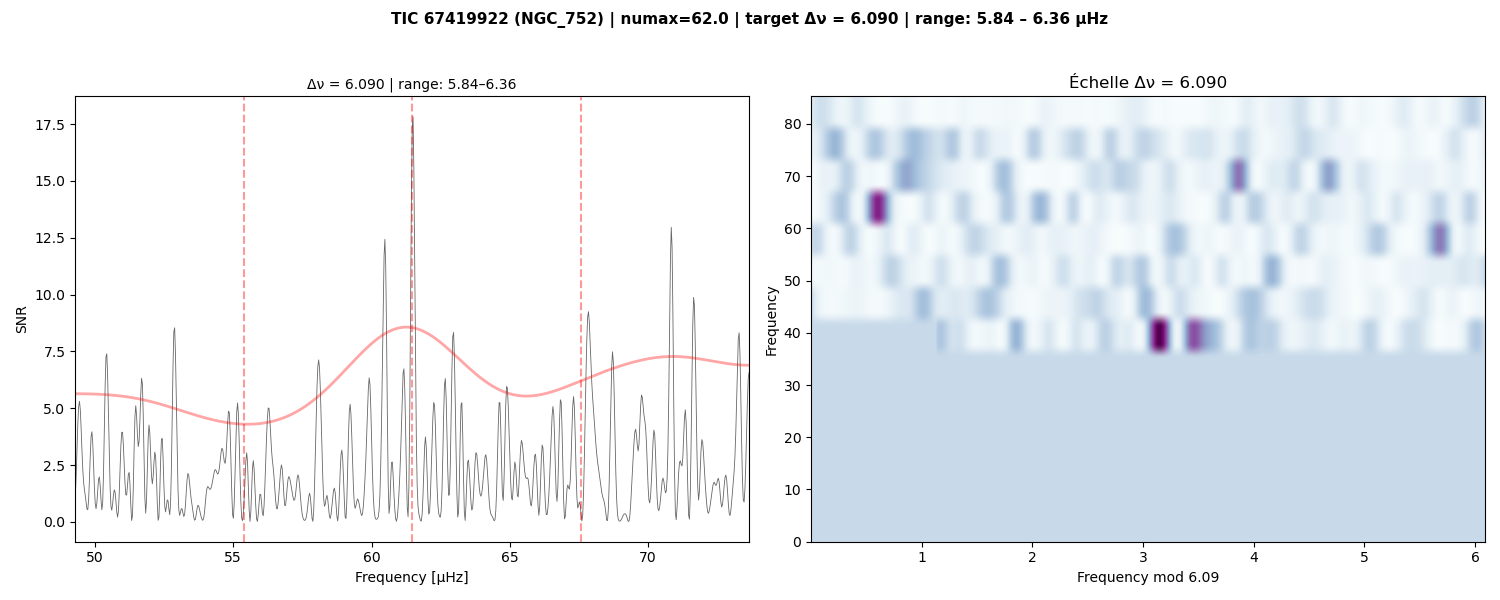

In [2]:
run_dnu(67419922, 62.00, 6.09, 5.84, 6.36, 'NGC_752')

### TIC 67569102 — NGC_752 | numax=66.4 | range: 4.99–7.75


In [ ]:
run_dnu(67569102, 66.40, 7.049, 4.985, 7.754, 'NGC_752')


### TIC 186970424 — NGC_752 [SPOC] | numax=62.5 | target Δν ≈ 6.0 (range 5.8–6.4)

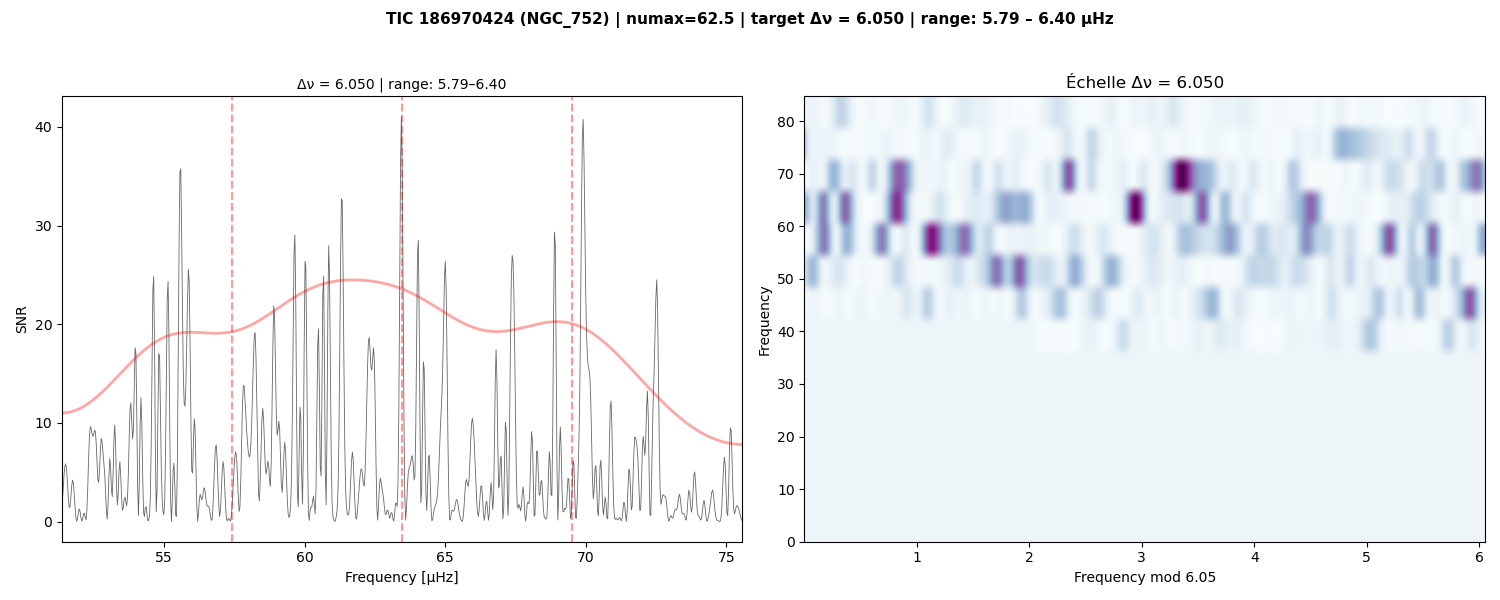

In [4]:
import shutil
shutil.copy('revision/spoc_data/186970424_SPOC_PS.txt', 'data/186970424_PS.txt')
run_dnu(186970424, 62.50, 6.05, 5.79, 6.40, 'NGC_752')

### TIC 67420118 — NGC_752 [SPOC] | numax=90 | target Δν ≈ 8.1 (range 7.7–8.5)

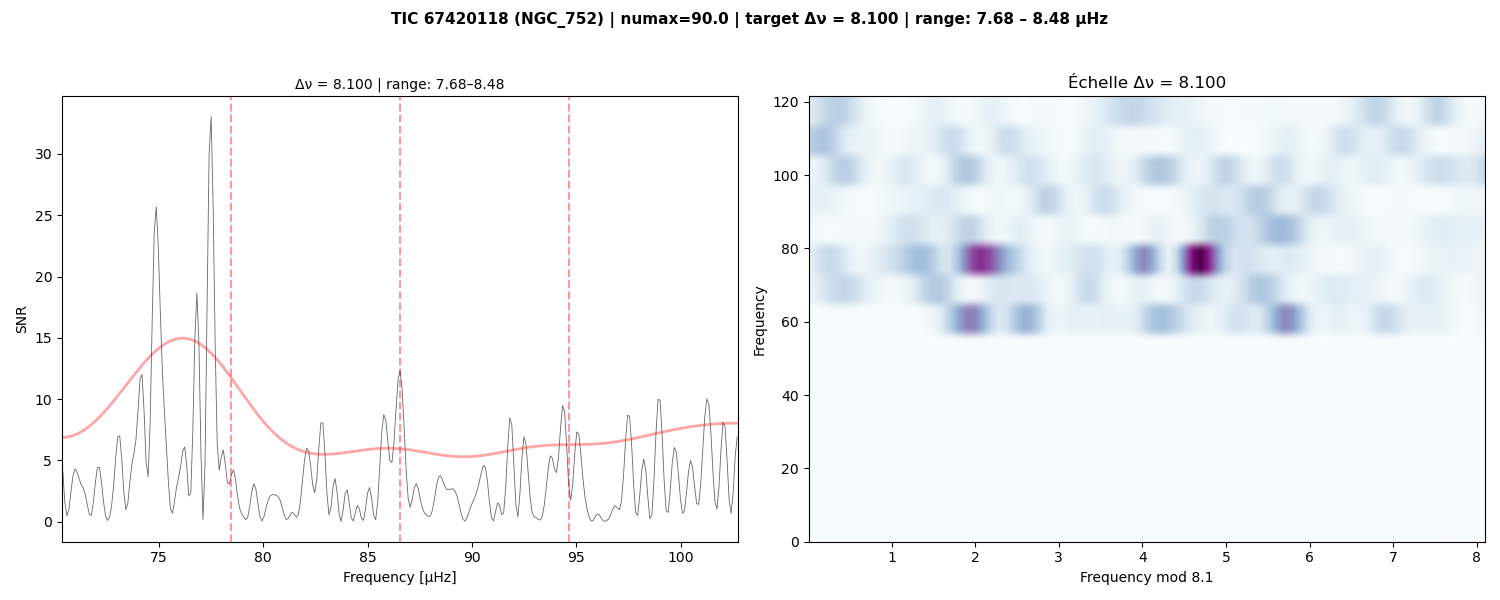

In [5]:
import shutil
shutil.copy('revision/spoc_data/67420118_SPOC_PS.txt', 'data/67420118_PS.txt')
run_dnu(67420118, 90.00, 8.10, 7.68, 8.48, 'NGC_752')

### TIC 150753375 — Theia_1188 | numax=15.2 | range: 1.85–2.49


In [ ]:
run_dnu(150753375, 15.20, 2.265, 1.846, 2.492, 'Theia_1188')


### TIC 321823630 — Theia_1297 | numax=26.3 | range: 2.90–3.80


In [ ]:
run_dnu(321823630, 26.30, 3.455, 2.904, 3.800, 'Theia_1297')


### TIC 43902016 — Theia_6046 [Hon+21] | numax=15.1 | range: 1.84–2.48


In [ ]:
run_dnu(43902016, 15.07, 2.250, 1.836, 2.475, 'Theia_6046')


### TIC 24444542 — Theia_6046 [Hon+21] | numax=16.6 | range: 1.93–2.66


In [ ]:
run_dnu(24444542, 16.58, 2.422, 1.926, 2.664, 'Theia_6046')


### TIC 306345133 — Theia_6046 [Hon+21] | numax=22.2 | range: 2.46–3.34


In [ ]:
run_dnu(306345133, 22.22, 3.034, 2.459, 3.338, 'Theia_6046')


### TIC 24666306 — Theia_6046 [Hon+21] | numax=33.3 | range: 3.29–4.56


In [ ]:
run_dnu(24666306, 33.29, 4.142, 3.286, 4.556, 'Theia_6046')


### TIC 34472483 — Theia_6046 [Hon+21] | numax=34.8 | range: 3.57–4.71


In [ ]:
run_dnu(34472483, 34.76, 4.282, 3.573, 4.711, 'Theia_6046')


### TIC 24297458 — Theia_6046 [Hon+21] | numax=56.0 | range: 4.82–6.80


In [ ]:
run_dnu(24297458, 56.01, 6.183, 4.824, 6.802, 'Theia_6046')


### TIC 249064439 — Theia_6046 [Hon+21] | numax=62.9 | range: 5.63–7.43


In [ ]:
run_dnu(249064439, 62.85, 6.757, 5.628, 7.433, 'Theia_6046')


### TIC 195862014 — Theia_844 | numax=62.1 | range: 4.60–7.36


In [ ]:
run_dnu(195862014, 62.10, 6.695, 4.597, 7.364, 'Theia_844')


### TIC 195860623 — Theia_844 | numax=109.1 | range: 7.05–11.37


In [ ]:
run_dnu(195860623, 109.10, 10.332, 7.046, 11.365, 'Theia_844')


### TIC 427725221 — UPK_226 | numax=33.2 | range: 3.35–4.55


In [ ]:
run_dnu(427725221, 33.20, 4.134, 3.347, 4.547, 'UPK_226')


### TIC 459055617 — Unknown_3 | numax=47.5 | range: 4.34–5.99


In [ ]:
run_dnu(459055617, 47.50, 5.446, 4.341, 5.991, 'Unknown_3')


### Record Dnu values


In [ ]:
measured_dnu = {
    # TIC: dnu,
}
if measured_dnu:
    import pandas as pd
    df = pd.DataFrame(list(measured_dnu.items()), columns=['TIC','dnu_measured'])
    df.to_csv('revision/measured_dnu_values.csv', index=False)
    print(f'Saved {len(df)}'); display(df)


### Quick Record — type your Δν after each target
Run this cell, then type values into the boxes. Click Save when done.


In [3]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

targets = [
    (352774198,'COIN-Gaia_30'), (306955660,'Casado_Alessi_1'),
    (306552813,'Casado_Alessi_1'), (306187638,'Casado_Alessi_1'),
    (140143506,'HSC_1986'), (402808611,'HSC_2615'),
    (414752508,'HSC_95'), (354016987,'LISC_3534'),
    (437030530,'NGC_2682'), (67419922,'NGC_752'),
    (67569102,'NGC_752'), (186970424,'NGC_752'),
    (67420118,'NGC_752'), (150753375,'Theia_1188'),
    (321823630,'Theia_1297'), (43902016,'Theia_6046'),
    (24444542,'Theia_6046'), (306345133,'Theia_6046'),
    (24666306,'Theia_6046'), (34472483,'Theia_6046'),
    (24297458,'Theia_6046'), (249064439,'Theia_6046'),
    (195862014,'Theia_844'), (195860623,'Theia_844'),
    (427725221,'UPK_226'), (459055617,'Unknown_3'),
]

boxes = {}
rows = []
for tic, cl in targets:
    label = widgets.Label(f'TIC {tic} ({cl}):', layout=widgets.Layout(width='250px'))
    box = widgets.FloatText(value=0, description='Δν:', step=0.001,
                            layout=widgets.Layout(width='200px'))
    boxes[tic] = box
    rows.append(widgets.HBox([label, box]))

def save_click(b):
    data = {tic: boxes[tic].value for tic, _ in targets if boxes[tic].value > 0}
    if data:
        df = pd.DataFrame(list(data.items()), columns=['TIC','dnu_measured'])
        df.to_csv('revision/measured_dnu_values.csv', index=False)
        status.value = f'<b style="color:green">Saved {len(data)} values to measured_dnu_values.csv</b>'
    else:
        status.value = '<b style="color:red">No values entered yet</b>'

save_btn = widgets.Button(description='Save All', button_style='success')
save_btn.on_click(save_click)
status = widgets.HTML(value='')

display(widgets.VBox(rows + [widgets.HBox([save_btn, status])]))
